In [1]:
import numpy as np
import matplotlib.pyplot as plt
from limpy.plotsettings import *
import limpy.theory as lt
import limpy.utils as lu

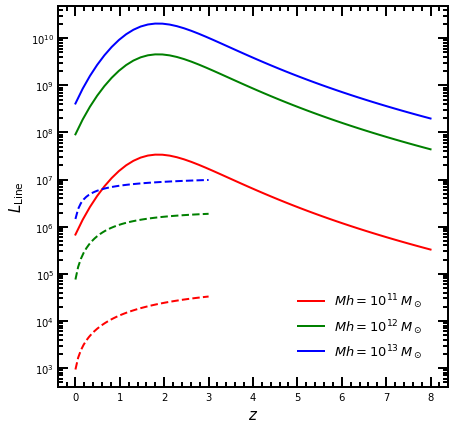

In [2]:
# Plot L_CII for different halo mass and redshift using LCII-Mhalo fitting formula
z=np.linspace(0, 8, num=50)
z_co=np.linspace(0, 3, num=50)

#for CII(J=1-0)
l_cii11=lt.mhalo_to_lline(10**11,z, line_name='CII')
l_cii12=lt.mhalo_to_lline(10**12,z, line_name='CII')
l_cii13=lt.mhalo_to_lline(10**13,z, line_name='CII')

#for CO(J=1-0)
l_co11=lt.mhalo_to_lline(10**11,z_co, line_name='CO10')
l_co12=lt.mhalo_to_lline(10**12,z_co, line_name='CO10')
l_co13=lt.mhalo_to_lline(10**13,z_co, line_name='CO10')


lw=2.0
plt.plot(z, l_cii11, lw=lw, color="r", label=r'$Mh=10^{11}\,M_\odot$')
plt.plot(z, l_cii12, lw=lw, color="g", label=r'$Mh=10^{12}\,M_\odot$')
plt.plot(z, l_cii13, lw=lw, color="b", label=r'$Mh=10^{13}\,M_\odot$')

plt.plot(z_co, l_co11, lw=lw, ls='--', color="r")
plt.plot(z_co, l_co12, lw=lw, ls='--',color="g")
plt.plot(z_co, l_co13, lw=lw, ls='--',color="b")

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$L_{\rm Line}$')
plt.legend(loc=0, frameon=False)

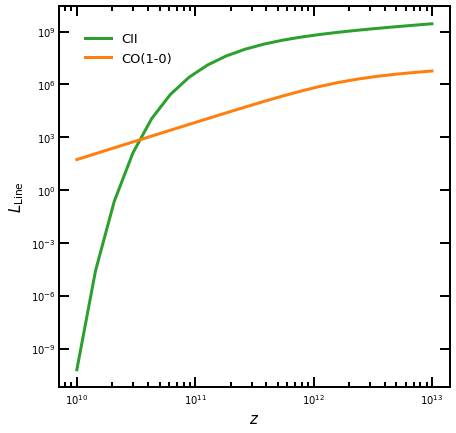

In [3]:
z=0.5
m=np.logspace(10,13,num=20)
l_ciim=lt.mhalo_to_lline(m,z, line_name='CII')
l_co10m=lt.mhalo_to_lline(m,z, line_name='CO10')

plt.plot(m,l_ciim,lw=3,color='C2', label='CII')
plt.plot(m,l_co10m,lw=3,color='C1', label='CO(1-0)')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$L_{\rm Line}$')
plt.legend(loc=0, frameon=False)

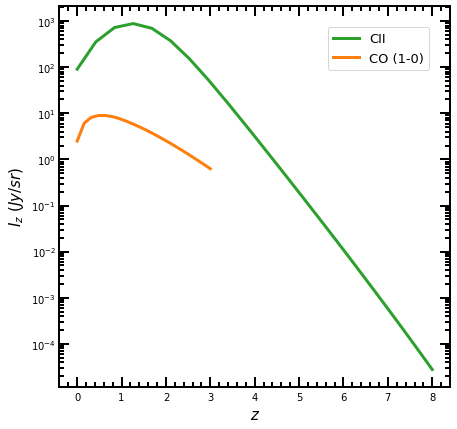

In [4]:
# Plot average intensity of CII and CO lines
z=np.linspace(0, 8, num=20)
z_co=np.linspace(0, 3, num=20)

nu_rest_CII=1900
nu_rest_CO10=115 #Ghz

Icii=[lt.I_line(zz, line_name='CII') for zz in z]
ICO10=Iav=[lt.I_line(z1, line_name='CO10') for z1 in z_co]
plt.plot(z, Icii, lw=3.0, color='C2',label="CII")
plt.plot(z_co, ICO10, lw=3.0, color='C1',label="CO (1-0)")

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$I_z\,\,(Jy/sr)$')
plt.legend(loc=0)

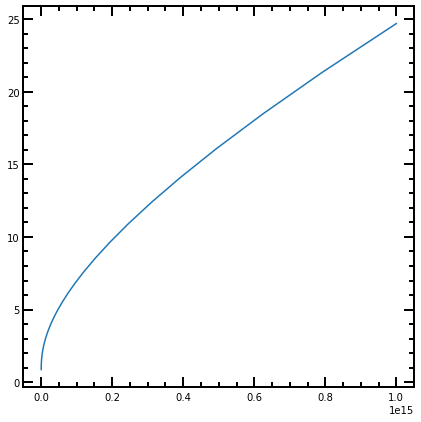

In [5]:
z=1.0
m=np.logspace(10,15)
b=lt.bias_dm(m,z)
plt.plot(m,b)


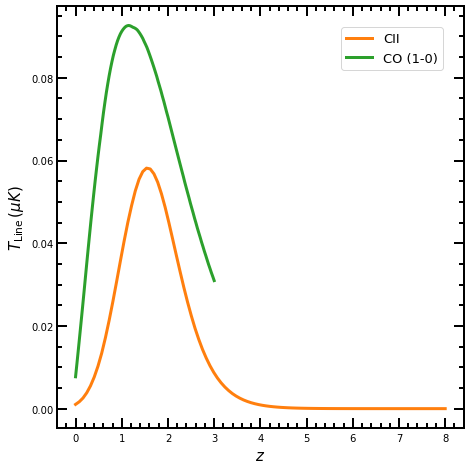

In [6]:
z=np.linspace(0, 8, num=100)
z_co=np.linspace(0, 3, num=100)

# Plot T_line for CII and CO lines
T_cii=[lt.T_line(zz,line_name="CII",fduty=0.1)*1e6 for zz in z]
T_co10=[lt.T_line(zz,line_name="CO10",fduty=0.1)*1e6 for zz in z_co]

plt.plot(z, T_cii, lw=3.0, color='C1',label="CII")
plt.plot(z_co, T_co10, lw=3.0, color='C2',label="CO (1-0)")

#plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_{\rm Line}\,(\mu K)$')
plt.legend(loc=0)
plt.tight_layout()
plt.savefig("temperature.png")

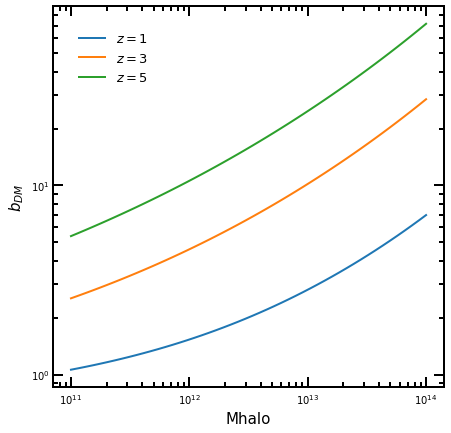

In [7]:
# plot Dark matter bias
m=np.logspace(11, 14)
pz1=lt.bias_dm(m,1.0)
pz3=lt.bias_dm(m,3.0)
pz5=lt.bias_dm(m,5.0)

plt.plot(m,pz1,lw=lw,label=r'$z=1$')
plt.plot(m,pz3,lw=lw,label=r'$z=3$')
plt.plot(m,pz5,lw=lw,label=r'$z=5$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mhalo')
plt.ylabel(r'$b_{DM}$')
plt.legend(loc=0, frameon=False)

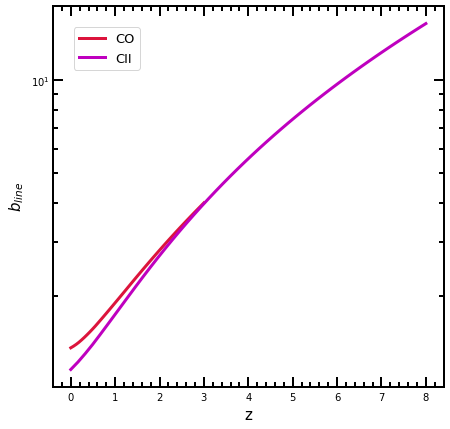

In [8]:
# plot bias of CII lines
z_c2=np.linspace(0, 8, num=50)
z_co=np.linspace(0, 3, num=50)

bline_co=[lt.b_line(zz, line_name='CO10') for zz in z_co]
bline_c2=[lt.b_line(zz, line_name='CII') for zz in z_c2]

plt.plot(z_co,bline_co,lw=3, color='crimson',label="CO")
plt.plot(z_c2,bline_c2,lw=3, color='m',label="CII")
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'$b_{line}$')
plt.legend(loc=0)

In [9]:
# plot all the power spectra
zline=3.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
pkshot_cii=lt.Pk_line(k,zline,line_name='CII', label='shot')
pkclus_cii=lt.Pk_line(k,zline,line_name='CII', label='clustering') 
pktotal_cii=lt.Pk_line(k,zline,line_name='CII', label='total')

In [10]:
# plot all the power spectra
zline=3.0
nu_rest_co=115 #GhZ
line_name='CO10'
pkshot_co=lt.Pk_line(k,zline,fduty=1.0,line_name=line_name, label='shot') 
pkclus_co=lt.Pk_line(k,zline,fduty=1.0,line_name=line_name,  label='clustering') 
pktotal_co=lt.Pk_line(k,zline,fduty=1.0,line_name=line_name,  label='total') 

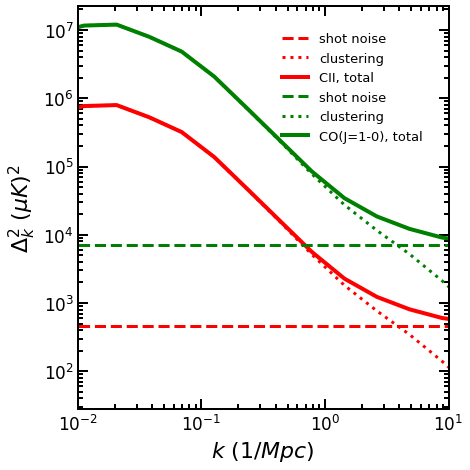

In [11]:

plt.plot(k, pkshot_cii*1e12, lw=3, ls='--', color='r', label="shot noise")
plt.plot(k, pkclus_cii*1e12, lw=3, ls=':', color='r',label="clustering")
plt.plot(k, pktotal_cii*1e12, lw=4, color='r',label="CII, total")

plt.plot(k, pkshot_co*1e12, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, pkclus_co*1e12, lw=3, ls=':', color='g',label="clustering")
plt.plot(k, pktotal_co*1e12, lw=4, color='g',label="CO(J=1-0), total")

plt.ylabel(r'$\Delta^2_k\,\,(\mu K)^2$')
plt.xlabel(r'$k\,\,(1/Mpc)$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)
plt.xlim(1e-2,1e1)
plt.tight_layout()
plt.savefig("pk_lines.png")

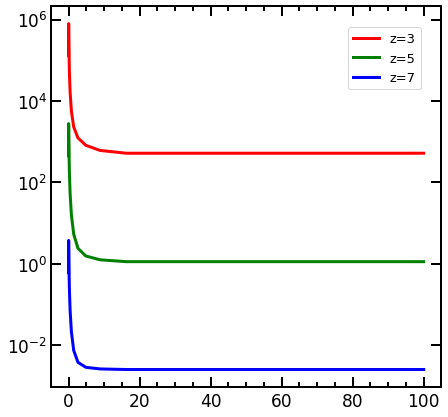

In [12]:
# plot all the power spectra
zline1=3.0
zline2=5.0
zline3=7.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
pktotal_cii_1=lt.Pk_line(k,zline1,line_name='CII', label='total')
pktotal_cii_2=lt.Pk_line(k,zline2,line_name='CII', label='total')
pktotal_cii_3=lt.Pk_line(k,zline3,line_name='CII', label='total')

plt.plot(k, pktotal_cii_1*1e12, lw=3, color='r', label="z=3")
plt.plot(k, pktotal_cii_2*1e12, lw=3,  color='g', label="z=5")
plt.plot(k, pktotal_cii_3*1e12, lw=3,  color='b', label="z=7")
plt.yscale("log")
plt.legend(loc=0)

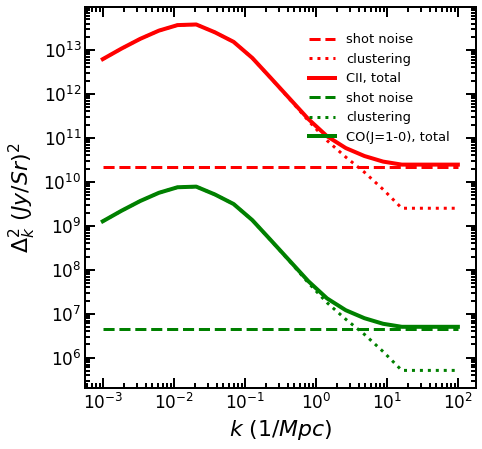

In [13]:
# Do it for intensity unit
zline=3.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
line_name='CII'
pkshot_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='shot',pk_unit='intensity')
pkclus_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='clustering',pk_unit='intensity') 
pktotal_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='total',pk_unit='intensity')

nu_rest_co=115 #GhZ
line_name='CO10'
pkshot_co=lt.Pk_line(k,zline,nu_rest_co,line_name=line_name,label='shot',pk_unit='intensity') 
pkclus_co=lt.Pk_line(k,zline,nu_rest_co,line_name=line_name,label='clustering',pk_unit='intensity') 
pktotal_co=lt.Pk_line(k,zline,nu_rest_co,line_name=line_name,label='total',pk_unit='intensity') 

plt.plot(k, pkshot_cii, lw=3, ls='--', color='r', label="shot noise")
plt.plot(k, pkclus_cii, lw=3, ls=':', color='r',label="clustering")
plt.plot(k, pktotal_cii, lw=4, color='r',label="CII, total")
plt.plot(k, pkshot_co, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, pkclus_co, lw=3, ls=':', color='g',label="clustering")
plt.plot(k, pktotal_co, lw=4, color='g',label="CO(J=1-0), total")

plt.ylabel(r'$\Delta^2_k\,\,(Jy/Sr)^2$')
plt.xlabel(r'$k\,\,(1/Mpc)$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)


In [14]:
ell=np.linspace(1,10000,num=10000)

In [15]:
z=3
deltaz=0.03
cl_cii=lt.Cl_line(ell, z, deltaz, fduty=1.0,line_name='CII')
cl_co=lt.Cl_line(ell, z, deltaz, fduty=1.0,line_name='CO10')

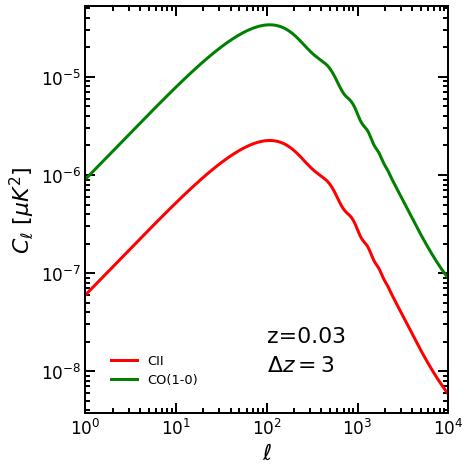

In [18]:
plt.loglog(ell,cl_cii*1e12,lw=3, color='r', label='CII')
plt.loglog(ell,cl_co*1e12,lw=3, color='g', label='CO(1-0)')
plt.legend(loc=0, frameon=False)
plt.xlim(1,1e4)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell\,\,[\mu K^2]$")
plt.annotate("z=0.03", xy=(100,2e-8))
plt.annotate(r"$\Delta z=3$", xy=(100,1e-8))
plt.savefig("cl_line.png")
plt.tight_layout()

In [17]:
import healpy as hp
np.random.seed(11)
map_cii=hp.synfast(cl_cii,nside=1024)

/Users/anirbanroy/opt/anaconda3/lib/python3.7/site-packages/healpy/sphtfunc.py:438: FutureChangeWarning: The order of the input cl's will change in a future release.
Use new=True keyword to start using the new order.
See documentation of healpy.synalm.
  category=FutureChangeWarning,
/Users/anirbanroy/opt/anaconda3/lib/python3.7/site-packages/healpy/sphtfunc.py:824: UserWarning: Sigma is 0.000000 arcmin (0.000000 rad) 
  sigma * 60 * 180 / np.pi, sigma
/Users/anirbanroy/opt/anaconda3/lib/python3.7/site-packages/healpy/sphtfunc.py:829: UserWarning: -> fwhm is 0.000000 arcmin
  sigma * 60 * 180 / np.pi * (2.0 * np.sqrt(2.0 * np.log(2.0)))


In [17]:
cl_cii

array([5.97171858e-20, 1.15215871e-19, 1.69427474e-19, ...,
       5.84592268e-21, 5.84521760e-21, 5.84451273e-21])

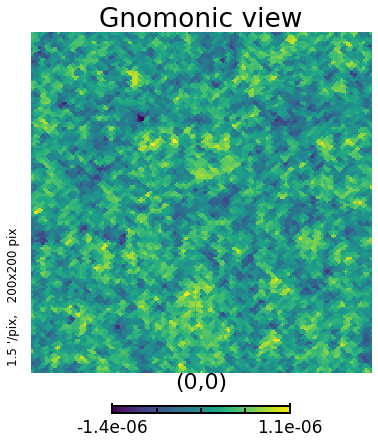

In [18]:
import matplotlib.colors as colors
hp.gnomview(map_cii)
plt.savefig("map_CII.png")

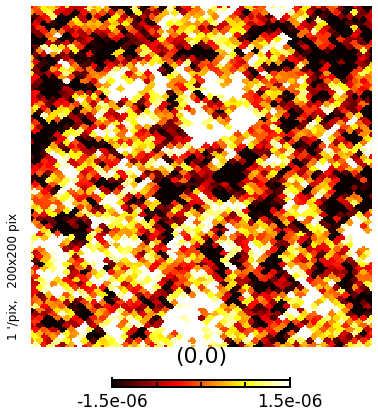

In [19]:
np.random.seed(11)
import healpy as hp
map_co=hp.synfast(cl_co,nside=1024)
hp.gnomview(map_co, reso=1,min=-1.5e-6, max=1.5e-6, title='',cmap=plt.cm.get_cmap('hot'))
plt.savefig("map_CO.png")

In [20]:
# Do it for intensity unit
zline=7.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
line_name='CII'
dktotal_cii=lt.Pk_line(k,zline,nu_rest_cii,line_name=line_name,label='total',pk_unit='intensity')

pk_line=dktotal_cii*2*np.pi**2/k**3

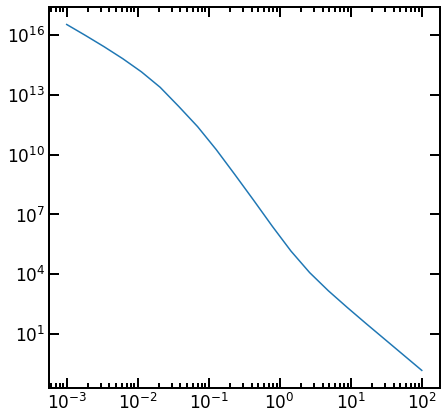

In [21]:
plt.loglog(k, pk_line)

In [22]:
Nm=lu.N_modes(k,7, 1, 16, 20, line_name='CII' )

In [23]:
varCII=(pk_line+lu.P_noise_ccatp())**2/Nm

In [24]:
SNR=pk_line/np.sqrt(varCII)
SNR

array([1.49933943e+00, 2.74826001e+00, 5.03750595e+00, 9.23363891e+00,
       1.69249737e+01, 3.10218928e+01, 5.68396403e+01, 1.03757717e+02,
       1.79265591e+02, 1.59643931e+02, 2.67767651e+01, 2.50976676e+00,
       2.60465415e-01, 3.95041234e-02, 8.87786316e-03, 2.40689587e-03,
       6.93752161e-04, 2.06485029e-04, 6.14572018e-05, 1.82918231e-05])

In [3]:
def SNR_line(k,nu_obs, delta_lnk, A_s, B_nu, line_name='CII'):
    z_line=lu.nu_obs_to_z(nu_obs, line_name=line_name)
    print("The redsfift of line is %2.2f" %(z_line))
    delta_k=k*10**(delta_lnk)
    
    Nm=lu.N_modes(k,z_line, delta_k, A_s, B_nu, line_name=line_name )
    pk_line=lt.Pk_line(k,z_line,line_name=line_name,label='total',pk_unit='intensity')

    varCII=((pk_line+lu.P_noise_ccatp(nu=nu_obs))**2)/Nm
    
    SNR=pk_line/np.sqrt(varCII)
    return SNR


def error_pk_line(k,nu_obs, delta_lnk, A_s, B_nu,  line_name='CII'):

    z_line=lu.nu_obs_to_z(nu_obs, line_name=line_name)
    print("The redsfift of line is %2.2f" %(z_line))
    delta_k=k*10**(delta_lnk)
    
    Nm=lu.N_modes(k,z_line, delta_k, A_s, B_nu, line_name=line_name )
    pk_line=lt.Pk_line(k,z_line,line_name=line_name,label='total',pk_unit='intensity')

    
    varCII=((pk_line+lu.P_noise_ccatp(nu=nu_obs))**2)/Nm
    return np.sqrt(varCII)


The redsfift of line is 5.79
The redsfift of line is 5.79


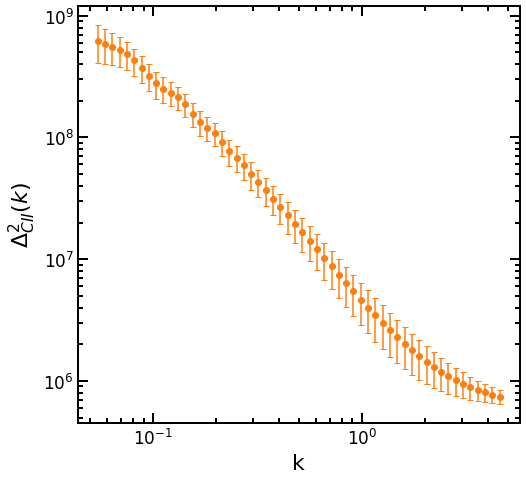

In [20]:

def k_binning(kmin, kmax, ln_deltak):
    bins=(np.log10(kmax)-np.log10(kmin))/ln_deltak
    kk=np.zeros(int(bins))
    delta=np.zeros(int(bins))
    for j in range(int(bins)):
        kk[j]=(kmin*10**(ln_deltak*(j)))
    
    delta_k=np.diff(kk)
    
    k_center=(kk[:-1]+delta_k)/2
    return k_center, delta_k
    
k_center, delta_k=k_binning(1e-1, 1e1, ln_deltak=0.035)

nu_obs=280
line_name='CII'
z_line=lu.nu_obs_to_z(nu_obs, line_name=line_name)
snr=SNR_line(k_center,nu_obs, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)

error_pk=error_pk_line(k_center,nu_obs, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)

dktotal_cii=lt.Pk_line(k_center,z_line,line_name=line_name,label='total',pk_unit='intensity')


#plt.plot(k_center, dktotal_cii, 'blue',lw=3)
plt.errorbar(k_center, dktotal_cii, yerr=error_pk, color='C1', fmt='o', capsize=3)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.xlabel("k")
plt.ylabel(r"$\Delta_{CII}^2(k)$")
plt.savefig("CII_error.png")

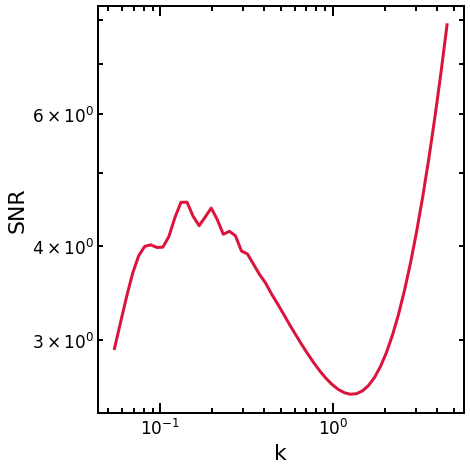

In [21]:
plt.plot(k_center,snr, color='crimson', lw=3)
plt.xlabel("k")
plt.ylabel("SNR") 
plt.yscale("log")
plt.xscale("log")
plt.tight_layout()
plt.savefig("SNR_CII_z7.png")

The redsfift of line is 7.64
The redsfift of line is 7.64
The redsfift of line is 5.79
The redsfift of line is 5.79
The redsfift of line is 4.43
The redsfift of line is 4.43
The redsfift of line is 3.63
The redsfift of line is 3.63


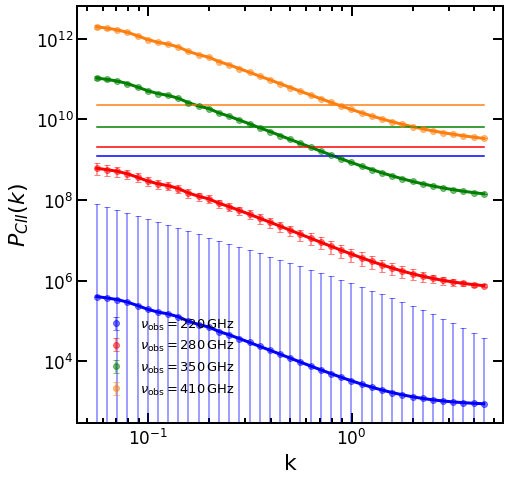

In [44]:
def k_binning(kmin, kmax, ln_deltak):
    bins=(np.log10(kmax)-np.log10(kmin))/ln_deltak
    kk=np.zeros(int(bins))
    delta=np.zeros(int(bins))
    for j in range(int(bins)):
        kk[j]=(kmin*10**(ln_deltak*(j)))
    
    delta_k=np.diff(kk)
    
    k_center=(kk[:-1]+delta_k)/2
    return k_center, delta_k
    
k_center, delta_k=k_binning(1e-1, 1e1, ln_deltak=0.1)

nu_obs1=220
nu_obs2=280
nu_obs3=350
nu_obs4=410


k_center, delta_k=k_binning(1e-1, 1e1, ln_deltak=0.05)

line_name='CII'
z_line1=lu.nu_obs_to_z(nu_obs1, line_name=line_name)
snr_1=SNR_line(k_center,nu_obs1, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
error_pk_1=error_pk_line(k_center,nu_obs1, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
dktotal_cii_1=lt.Pk_line(k_center,z_line1,line_name=line_name,label='total',pk_unit='intensity')

z_line2=lu.nu_obs_to_z(nu_obs2, line_name=line_name)
snr_2=SNR_line(k_center,nu_obs2, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
error_pk_2=error_pk_line(k_center,nu_obs2, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
dktotal_cii_2=lt.Pk_line(k_center,z_line2,line_name=line_name,label='total',pk_unit='intensity')

z_line3=lu.nu_obs_to_z(nu_obs3, line_name=line_name)
snr_3=SNR_line(k_center,nu_obs3, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
error_pk_3=error_pk_line(k_center,nu_obs3, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
dktotal_cii_3=lt.Pk_line(k_center,z_line3,line_name=line_name,label='total',pk_unit='intensity')

z_line4=lu.nu_obs_to_z(nu_obs4, line_name=line_name)
snr_4=SNR_line(k_center,nu_obs4, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
error_pk_4=error_pk_line(k_center,nu_obs4, delta_lnk=delta_k, A_s=8, B_nu=20, line_name=line_name)
dktotal_cii_4=lt.Pk_line(k_center,z_line4,line_name=line_name,label='total',pk_unit='intensity')


plt.plot(k_center, dktotal_cii_1, 'blue',lw=3)
plt.plot(k_center, dktotal_cii_2, 'red',lw=3)
plt.plot(k_center, dktotal_cii_3, 'g',lw=3)
plt.plot(k_center, dktotal_cii_4, 'C1',lw=3)


plt.errorbar(k_center, dktotal_cii_1, yerr=error_pk_1, color='blue', fmt='o', capsize=3, alpha=0.5, label=r"$\nu_{\rm obs}=220\, \mathrm{GHz}$" )
plt.errorbar(k_center, dktotal_cii_2, yerr=error_pk_2, color='red', fmt='o', capsize=3, alpha=0.5, label=r"$\nu_{\rm obs}=280\, \mathrm{GHz}$")
plt.errorbar(k_center, dktotal_cii_3, yerr=error_pk_3, color='g', fmt='o', capsize=3, alpha=0.5, label=r"$\nu_{\rm obs}=350\, \mathrm{GHz}$")
plt.errorbar(k_center, dktotal_cii_4, yerr=error_pk_4, color='C1', fmt='o', capsize=3, alpha=0.5, label=r"$\nu_{\rm obs}=410\, \mathrm{GHz}$")

klen=len(k_center)
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs1)*np.ones(klen), color='blue')
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs2)*np.ones(klen), color='red')
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs3)*np.ones(klen), color='g')
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs4)*np.ones(klen), color='C1')

plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.xlabel("k")
plt.ylabel(r"$P_{CII}(k)$")
plt.savefig("PCII_error.png")
plt.legend(loc=0, frameon=False)

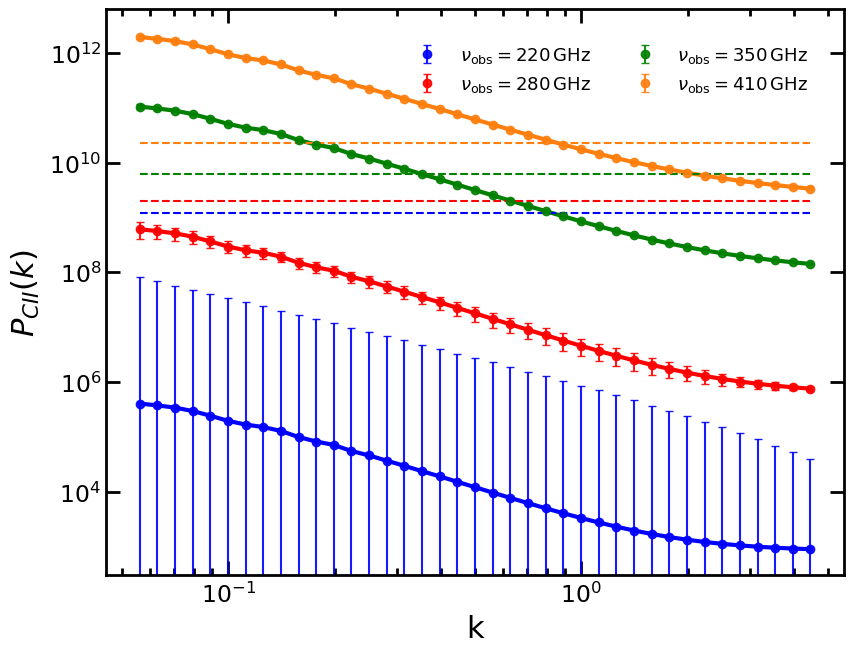

In [56]:
plt.figure(figsize=(9,7), dpi=100)
plt.plot(k_center, dktotal_cii_1, 'blue',lw=3)
plt.plot(k_center, dktotal_cii_2, 'red',lw=3)
plt.plot(k_center, dktotal_cii_3, 'g',lw=3)
plt.plot(k_center, dktotal_cii_4, 'C1',lw=3)


plt.errorbar(k_center, dktotal_cii_1, yerr=error_pk_1, color='blue', fmt='o', capsize=3, alpha=0.9, label=r"$\nu_{\rm obs}=220\, \mathrm{GHz}$" )
plt.errorbar(k_center, dktotal_cii_2, yerr=error_pk_2, color='red', fmt='o', capsize=3, alpha=0.9, label=r"$\nu_{\rm obs}=280\, \mathrm{GHz}$")
plt.errorbar(k_center, dktotal_cii_3, yerr=error_pk_3, color='g', fmt='o', capsize=3, alpha=0.9, label=r"$\nu_{\rm obs}=350\, \mathrm{GHz}$")
plt.errorbar(k_center, dktotal_cii_4, yerr=error_pk_4, color='C1', fmt='o', capsize=3, alpha=0.9, label=r"$\nu_{\rm obs}=410\, \mathrm{GHz}$")

klen=len(k_center)
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs1)*np.ones(klen), '--',  color='blue')
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs2)*np.ones(klen), '--', color='red')
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs3)*np.ones(klen), '--', color='g')
plt.plot(k_center, lu.P_noise_ccatp(nu=nu_obs4)*np.ones(klen), '--', color='C1')

plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.xlabel("k")
plt.ylabel(r"$P_{CII}(k)$")
plt.legend(loc=1, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("PCII_error.png")

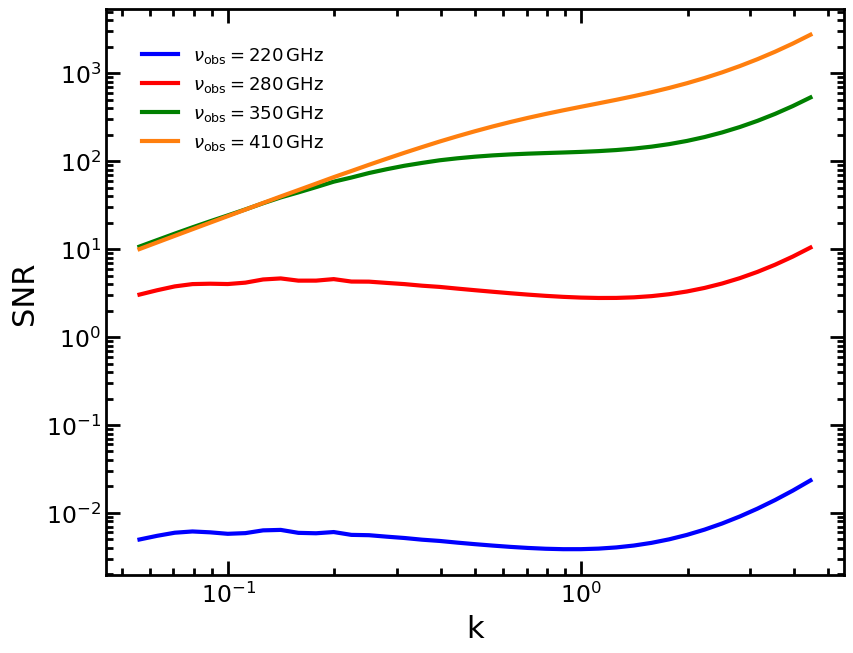

In [61]:
plt.figure(figsize=(9,7), dpi=100)
lw=3
plt.plot(k_center, snr_1, lw=lw, color='blue', label=r"$\nu_{\rm obs}=220\, \mathrm{GHz}$")
plt.plot(k_center, snr_2, lw=lw, color='red', label=r"$\nu_{\rm obs}=280\, \mathrm{GHz}$")
plt.plot(k_center, snr_3, lw=lw, color='g', label=r"$\nu_{\rm obs}=350\, \mathrm{GHz}$")
plt.plot(k_center, snr_4, lw=lw, color='C1', label=r"$\nu_{\rm obs}=410\, \mathrm{GHz}$")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("SNR")
plt.xlabel("k")
plt.legend(loc=0, frameon=False)
plt.tight_layout()
plt.savefig("SNR.png")

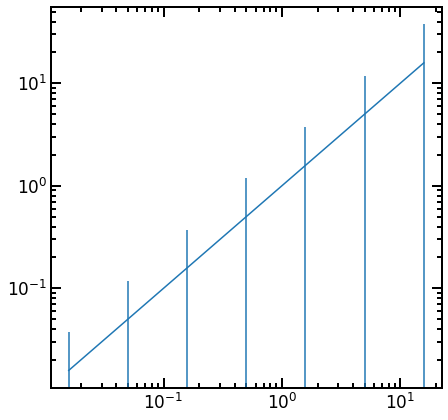

In [41]:
kmax=1e2
kmin=1e-2
k=np.linspace(10**-2,10**2)
deltak=0.5
bins=(np.log10(kmax)-np.log10(kmin))/deltak
kk=np.zeros(int(bins))
delta=np.zeros(int(bins))
for j in range(int(bins)):
    kk[j]=(kmin*10**(deltak*(j)))
    
    
delta_k=np.diff(kk)
    
k_center=(kk[:-1]+delta_k)/2




#plt.scatter(kk,kk)
plt.errorbar(k_center,k_center, yerr=delta_k)
plt.xscale('log')
plt.yscale('log')